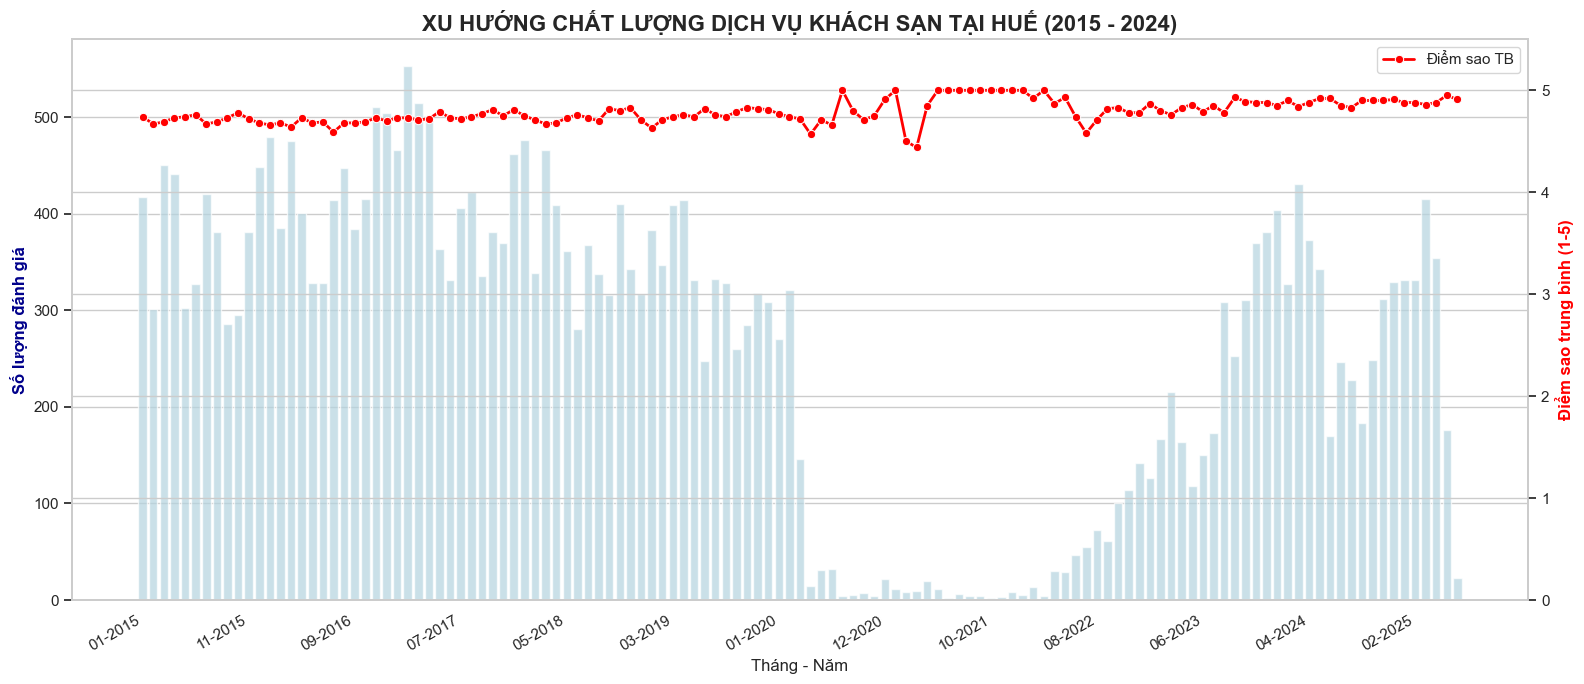

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

df_trend = pd.read_csv('nhom3_output/trend_monthly.csv')
df_trend['year_month'] = pd.to_datetime(df_trend['year_month'])

# 2. Lọc dữ liệu từ năm 2015 
df_filtered = df_trend[df_trend['year_month'] >= '2015-01'].copy()


sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(16, 7))


sns.barplot(data=df_filtered, 
            x=df_filtered['year_month'].dt.strftime('%m-%Y'), 
            y='total_reviews', 
            ax=ax1, color='lightblue', alpha=0.7)

ax1.set_ylabel('Số lượng đánh giá', fontsize=12, fontweight='bold', color='darkblue')
ax1.set_xlabel('Tháng - Năm', fontsize=12)

# 4. Tạo trục Y thứ hai cho Điểm Sao (Trục Y bên phải)
ax2 = ax1.twinx()
# Dùng range(len) để khớp vị trí các cột của bar chart
sns.lineplot(x=range(len(df_filtered)), 
             y=df_filtered['avg_star'], 
             ax=ax2, color='red', marker='o', markersize=6, linewidth=2, label='Điểm sao TB')

ax2.set_ylabel('Điểm sao trung bình (1-5)', fontsize=12, fontweight='bold', color='red')
ax2.set_ylim(0, 5.5)

# 5. XỬ LÝ TRỤC X: Chỉ hiện tối đa 15 nhãn để không bị dày đặc
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=15))
plt.gcf().autofmt_xdate()

plt.title('XU HƯỚNG CHẤT LƯỢNG DỊCH VỤ KHÁCH SẠN TẠI HUẾ (2015 - 2024)', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

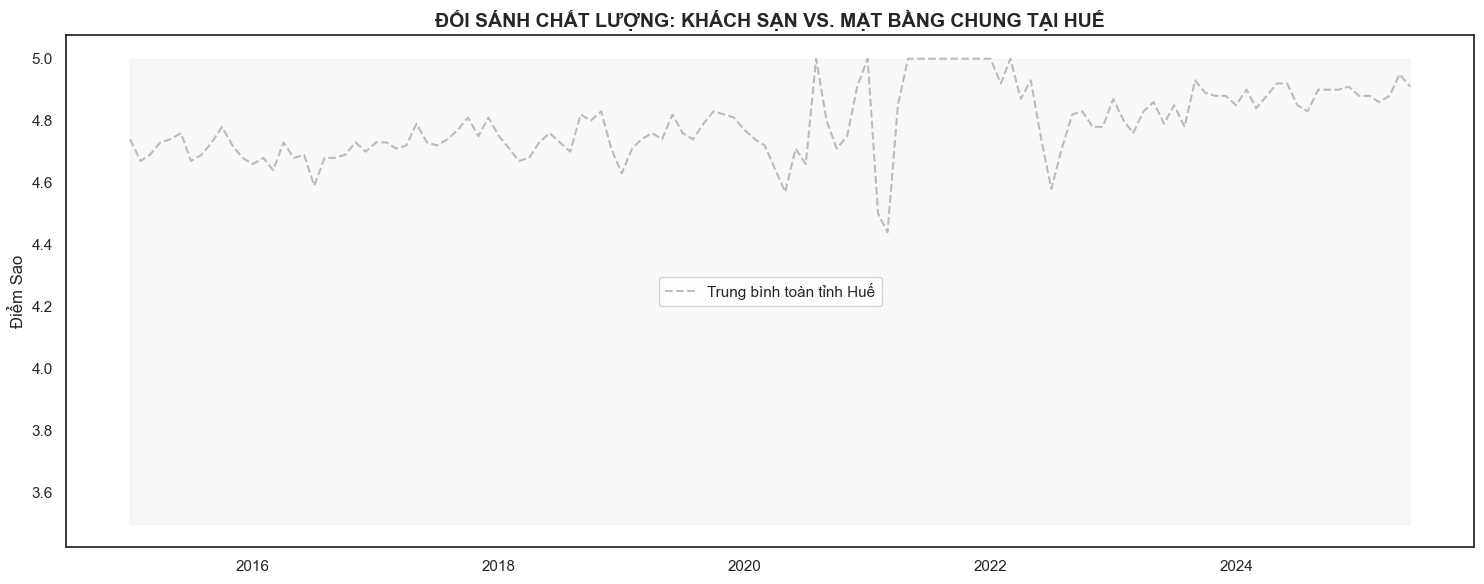

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Giả sử df_trend là dữ liệu tổng hợp toàn tỉnh từ 2015
df_hue_avg = df_trend[df_trend['year_month'] >= '2015-01-01'].groupby('year_month')['avg_star'].mean().reset_index()

# 2. Lấy dữ liệu của 1 khách sạn tiêu biểu (ví dụ: Charming Riverside)
# Giả sử bạn có file chứa dữ liệu riêng từng khách sạn theo tháng
# df_hotel = df_all[df_all['hotel_name'] == 'Charming Riverside Hotel']

plt.figure(figsize=(15, 6))
sns.set_theme(style="white")

# Vẽ đường trung bình toàn tỉnh (Làm nền)
plt.plot(df_hue_avg['year_month'], df_hue_avg['avg_star'], 
         label='Trung bình toàn tỉnh Huế', color='gray', linestyle='--', alpha=0.5)

# Vẽ đường của khách sạn cụ thể (Để đối sánh)
# plt.plot(df_hotel['year_month'], df_hotel['avg_star'], 
#          label='Charming Riverside', color='blue', linewidth=2)

plt.fill_between(df_hue_avg['year_month'], 3.5, 5, color='gray', alpha=0.05) # Vùng kỳ vọng

plt.title('ĐỐI SÁNH CHẤT LƯỢNG: KHÁCH SẠN VS. MẶT BẰNG CHUNG TẠI HUẾ', fontsize=14, fontweight='bold')
plt.ylabel('Điểm Sao')
plt.legend()
plt.tight_layout()
plt.show()

(92.0, 95.0)

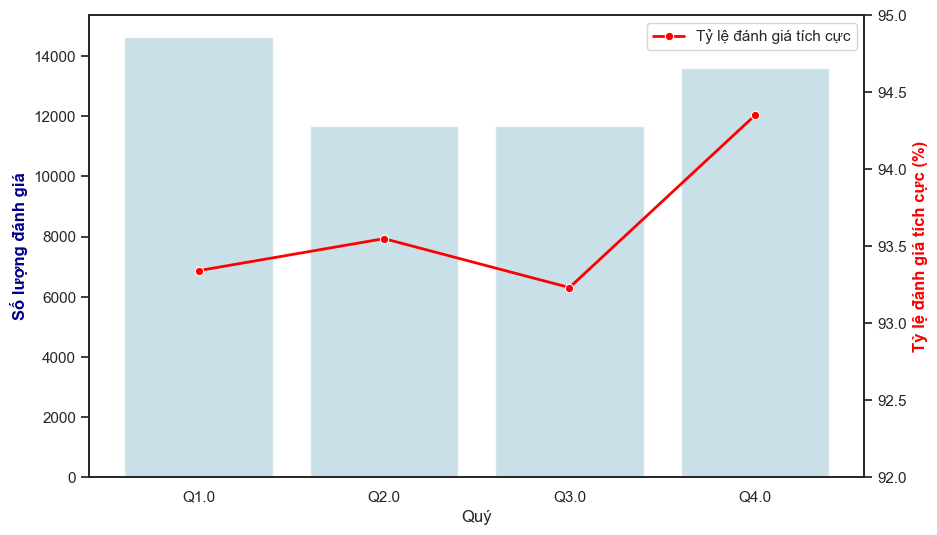

In [14]:
df_quarterly = pd.read_csv('nhom3_output/trend_quarterly.csv')
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(data=df_quarterly,
            x=df_quarterly['visit_quarter'], 
            y='total_reviews', 
            ax=ax1, color='lightblue', alpha=0.7)
ax1.set_ylabel('Số lượng đánh giá', fontsize=12, fontweight='bold', color='darkblue')
ax1.set_xlabel('Quý', fontsize=12)

ax2 =ax1.twinx()
sns.lineplot(x=df_quarterly['visit_quarter'],y='pct_positive',data=df_quarterly, ax=ax2, color='red', marker='o', markersize=6, linewidth=2, label='Tỷ lệ đánh giá tích cực')
ax2.set_ylabel('Tỷ lệ đánh giá tích cực (%)', fontsize=12, fontweight='bold', color='red')
ax2.set_ylim(92,95)    

AttributeError: 'Figure' object has no attribute 'yaxis'

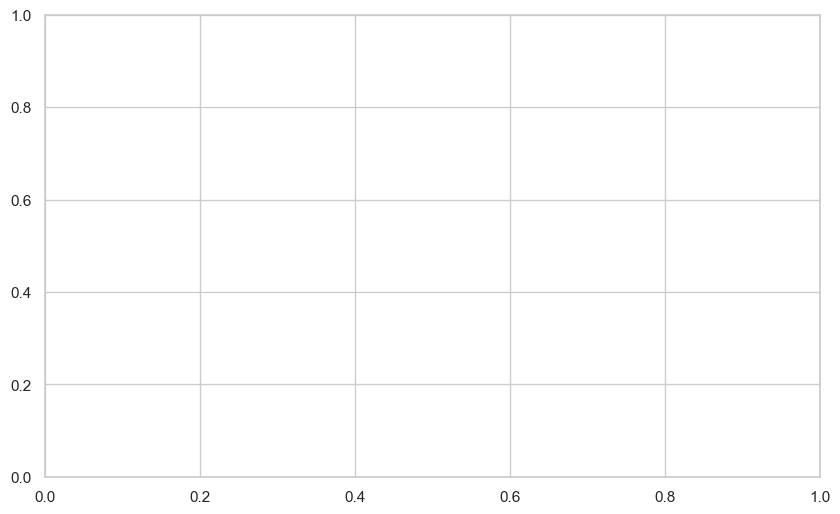

In [ ]:
df_triptye=pd.read_csv('nhom3_output/triptype_overview.csv')
fig, ax1 = plt.subplots(figsize=(10,6))

sns.barplot(data=df_triptye,x=df_triptye['trip_type'],y='total_reviews',ax=ax1,color='lightblue',alpha=0.7)
ax1.set_ylabel('Số lượng đánh giá', fontsize=12, fontweight='bold', color='darkblue')
ax1.set_xlabel('Loại du lịch', fontsize=12)